In [1]:
!pip install torch torchvision --quiet

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import os

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
data_dir = "/kaggle/input/datasets/venkatsaikondra/venkatsaikondra67/Final_Data"

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [5]:
train_dataset = datasets.ImageFolder(os.path.join(data_dir, "train"), transform=train_transform)
val_dataset = datasets.ImageFolder(os.path.join(data_dir, "val"), transform=val_transform)
test_dataset = datasets.ImageFolder(os.path.join(data_dir, "test"), transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

class_names = train_dataset.classes
print("Classes:", class_names)

Classes: ['Covid-19', 'Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral']


In [6]:
labels = train_dataset.targets
class_weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

In [7]:
model = models.resnet50(pretrained=True)

# Modify final layer
model.fc = nn.Linear(model.fc.in_features, len(class_names))

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 200MB/s]


In [8]:
for param in model.parameters():
    param.requires_grad = False

# Unfreeze final layer
for param in model.fc.parameters():
    param.requires_grad = True

In [9]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=2, factor=0.3
)

In [10]:
def train_model(model, train_loader, val_loader, epochs=30):
    best_f1 = 0.0
    scaler = torch.cuda.amp.GradScaler()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        # Validation
        model.eval()
        val_preds = []
        val_labels = []
        val_loss = 0.0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)

                _, preds = torch.max(outputs, 1)
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        val_loss = val_loss / len(val_loader.dataset)
        val_acc = (np.array(val_preds) == np.array(val_labels)).mean()
        val_f1 = f1_score(val_labels, val_preds, average='macro')

        scheduler.step(val_f1)

        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), "best_model_resnet50.pth")

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")
        print(f"Best F1: {best_f1:.4f}")
        print("-"*50)

    model.load_state_dict(torch.load("best_model_resnet50.pth"))
    return model

In [11]:
model = train_model(model, train_loader, val_loader, epochs=10)

/tmp/ipykernel_55/2467640356.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_55/2467640356.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/10
Train Loss: 0.9095 | Train Acc: 0.6722
Val Loss: 0.6979 | Val Acc: 0.7550 | Val F1: 0.7450
Best F1: 0.7450
--------------------------------------------------


/tmp/ipykernel_55/2467640356.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 2/10
Train Loss: 0.6666 | Train Acc: 0.7554
Val Loss: 0.6100 | Val Acc: 0.7778 | Val F1: 0.7757
Best F1: 0.7757
--------------------------------------------------


/tmp/ipykernel_55/2467640356.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...

Epoch 8/10
Train Loss: 0.5074 | Train Acc: 0.8009
Val Loss: 0.4936 | Val Acc: 0.8088 | Val F1: 0.8046
Best F1: 0.8046
--------------------------------------------------


/tmp/ipykernel_55/2467640356.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 9/10
Train Loss: 0.5028 | Train Acc: 0.7985
Val Loss: 0.4808 | Val Acc: 0.8187 | Val F1: 0.8174
Best F1: 0.8174
--------------------------------------------------


/tmp/ipykernel_55/2467640356.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 10/10
Train Loss: 0.5052 | Train Acc: 0.8007
Val Loss: 0.4858 | Val Acc: 0.8181 | Val F1: 0.8178
Best F1: 0.8178
--------------------------------------------------


In [12]:
for param in model.layer4.parameters():
    param.requires_grad = True

In [13]:
model = train_model(model, train_loader, val_loader, epochs=20)

/tmp/ipykernel_55/2467640356.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_55/2467640356.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/20
Train Loss: 0.4717 | Train Acc: 0.8090
Val Loss: 0.3448 | Val Acc: 0.8546 | Val F1: 0.8537
Best F1: 0.8537
--------------------------------------------------


/tmp/ipykernel_55/2467640356.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 2/20
Train Loss: 0.3539 | Train Acc: 0.8511
Val Loss: 0.2929 | Val Acc: 0.8762 | Val F1: 0.8755
Best F1: 0.8755
--------------------------------------------------


/tmp/ipykernel_55/2467640356.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...

Epoch 18/20
Train Loss: 0.0541 | Train Acc: 0.9799
Val Loss: 0.2459 | Val Acc: 0.9264 | Val F1: 0.9262
Best F1: 0.9327
--------------------------------------------------


/tmp/ipykernel_55/2467640356.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 19/20
Train Loss: 0.0469 | Train Acc: 0.9830
Val Loss: 0.2483 | Val Acc: 0.9264 | Val F1: 0.9262
Best F1: 0.9327
--------------------------------------------------


/tmp/ipykernel_55/2467640356.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 20/20
Train Loss: 0.0458 | Train Acc: 0.9846
Val Loss: 0.2402 | Val Acc: 0.9332 | Val F1: 0.9332
Best F1: 0.9332
--------------------------------------------------


In [14]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))

                     precision    recall  f1-score   support

           Covid-19       0.99      1.00      0.99       405
             Normal       0.99      0.97      0.98       405
Pneumonia-Bacterial       0.88      0.82      0.85       405
    Pneumonia-Viral       0.82      0.89      0.85       405

           accuracy                           0.92      1620
          macro avg       0.92      0.92      0.92      1620
       weighted avg       0.92      0.92      0.92      1620



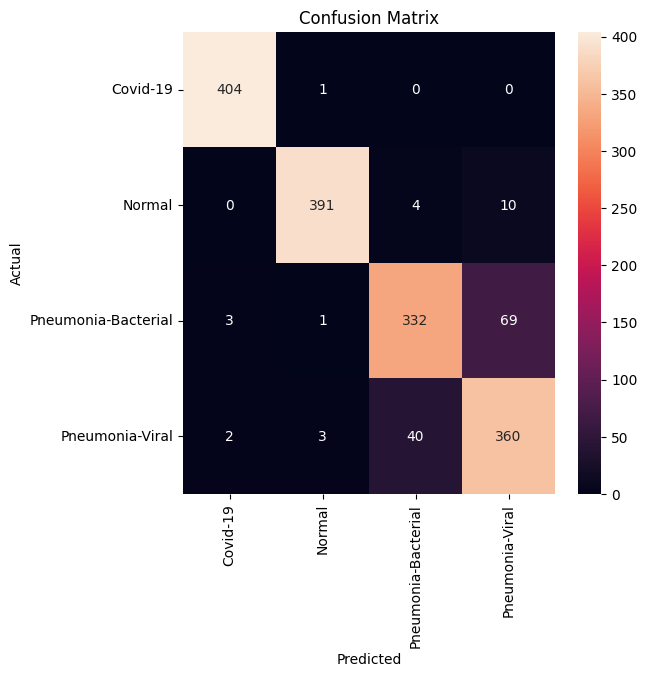

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

In [20]:
# Number of classes (change this based on your dataset)
num_classes = all_probs.shape[1]

# Convert labels to one-hot format
all_labels_bin = label_binarize(all_labels, classes=list(range(num_classes)))

In [21]:
fpr = {}
tpr = {}
roc_auc = {}

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

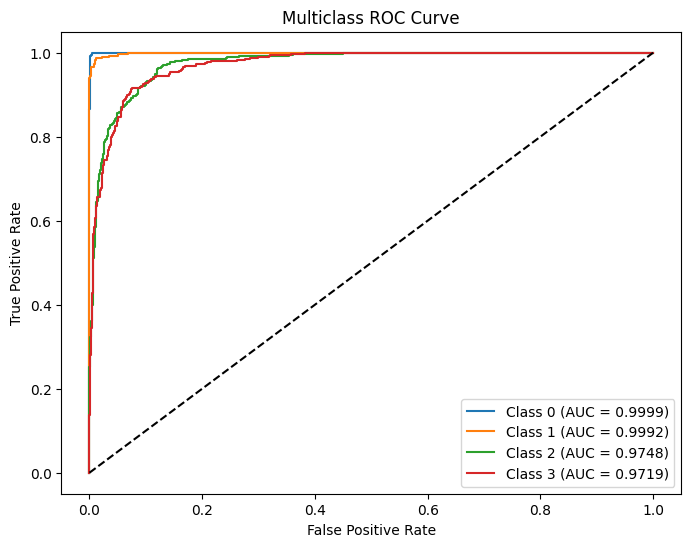

In [22]:
plt.figure(figsize=(8, 6))

for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.4f})")

plt.plot([0, 1], [0, 1], 'k--')  # diagonal

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve")
plt.legend()
plt.show()

In [23]:
import torch
import torch.nn.functional as F
import cv2
import numpy as np

In [25]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

        self.gradients = None
        self.activations = None

        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, input_tensor, class_idx):
        self.model.zero_grad()

        output = self.model(input_tensor)
        loss = output[:, class_idx]
        loss.backward()

        gradients = self.gradients
        activations = self.activations

        weights = torch.mean(gradients, dim=(2, 3), keepdim=True)
        cam = torch.sum(weights * activations, dim=1)

        cam = F.relu(cam)
        cam = cam.squeeze().cpu().detach().numpy()

        cam = cv2.resize(cam, (224, 224))
        cam = (cam - cam.min()) / (cam.max() + 1e-8)

        return cam

In [26]:
target_layer = model.layer4[-1]  # ResNet50 last conv layer
grad_cam = GradCAM(model, target_layer)

In [29]:
sample_img, label = next(iter(test_loader))
sample_img = sample_img.to(device)

mask = grad_cam.generate(sample_img[0:1], class_idx=label[0].item())

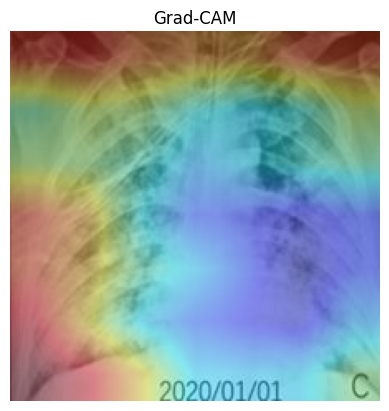

In [30]:
img = sample_img[0].permute(1, 2, 0).cpu().numpy()
img = (img - img.min()) / (img.max() + 1e-8)

heatmap = cv2.applyColorMap(np.uint8(255 * mask), cv2.COLORMAP_JET)
heatmap = np.float32(heatmap) / 255

overlay = heatmap + img
overlay = overlay / np.max(overlay)

plt.imshow(overlay)
plt.axis('off')
plt.title("Grad-CAM")
plt.show()

In [32]:
import numpy as np
import torch
import cv2

In [34]:
def generate_masks(N, s, p1):
    masks = []

    for _ in range(N):
        mask = np.random.choice([0, 1], size=(s, s), p=[1-p1, p1])
        mask = cv2.resize(mask.astype(np.float32), (224, 224))
        masks.append(mask)

    return np.array(masks)

In [35]:
class RISE:
    def __init__(self, model, N=1000, s=7, p1=0.5):
        self.model = model
        self.N = N
        self.s = s
        self.p1 = p1

        self.masks = generate_masks(N, s, p1)

    def explain(self, image, class_idx):
        preds = []

        for i in range(self.N):
            mask = torch.tensor(self.masks[i]).unsqueeze(0).to(device)
            masked_img = image * mask

            output = self.model(masked_img)
            prob = torch.softmax(output, dim=1)[0, class_idx]

            preds.append(prob.item())

        preds = np.array(preds)
        saliency = np.tensordot(preds, self.masks, axes=(0, 0))

        saliency = saliency / (self.N * self.p1)
        return saliency

In [36]:
rise = RISE(model, N=500, s=8, p1=0.5)

In [37]:
sample_img, label = next(iter(test_loader))
sample_img = sample_img.to(device)

saliency = rise.explain(sample_img[0:1], class_idx=label[0].item())

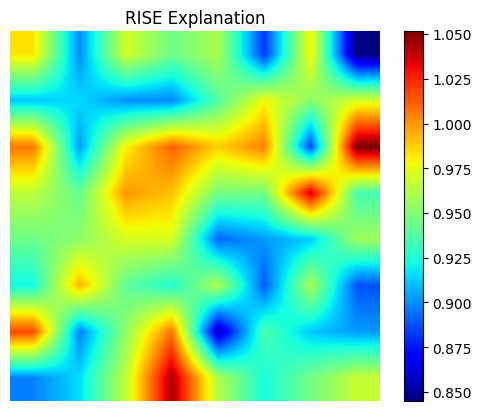

In [38]:
plt.imshow(saliency, cmap='jet')
plt.colorbar()
plt.title("RISE Explanation")
plt.axis('off')
plt.show()